<h2>Categorical Variables and One Hot Encoding</h2>

In [132]:
import pandas as pd

In [133]:
df = pd.read_csv("homeprices.csv")
df

,town,area,price
0,monroe township,2600,550000
1,monroe township,3000,565000
2,monroe township,3200,610000
3,monroe township,3600,680000
4,monroe township,4000,725000
5,west windsor,2600,585000
6,west windsor,2800,615000
7,west windsor,3300,650000
8,west windsor,3600,710000
9,robinsville,2600,575000


<h2 style='color:purple'>Using pandas to create dummy variables</h2>

In [134]:
dummies = pd.get_dummies(df.town)
dummies

,monroe township,robinsville,west windsor
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,True,False,False
5,False,False,True
6,False,False,True
7,False,False,True
8,False,False,True
9,False,True,False


In [135]:
merged = pd.concat([df,dummies],axis='columns')
merged

,town,area,price,monroe township,robinsville,west windsor
0,monroe township,2600,550000,True,False,False
1,monroe township,3000,565000,True,False,False
2,monroe township,3200,610000,True,False,False
3,monroe township,3600,680000,True,False,False
4,monroe township,4000,725000,True,False,False
5,west windsor,2600,585000,False,False,True
6,west windsor,2800,615000,False,False,True
7,west windsor,3300,650000,False,False,True
8,west windsor,3600,710000,False,False,True
9,robinsville,2600,575000,False,True,False


In [136]:
final = merged.drop(['town'], axis='columns')
final

,area,price,monroe township,robinsville,west windsor
0,2600,550000,True,False,False
1,3000,565000,True,False,False
2,3200,610000,True,False,False
3,3600,680000,True,False,False
4,4000,725000,True,False,False
5,2600,585000,False,False,True
6,2800,615000,False,False,True
7,3300,650000,False,False,True
8,3600,710000,False,False,True
9,2600,575000,False,True,False


<h3 style='color:purple'>Dummy Variable Trap</h3>

When you can derive one variable from other variables, they are known to be multi-colinear. Here
if you know values of california and georgia then you can easily infer value of new jersey state, i.e. 
california=0 and georgia=0. There for these state variables are called to be multi-colinear. In this
situation linear regression won't work as expected. Hence you need to drop one column. 

**NOTE: sklearn library takes care of dummy variable trap hence even if you don't drop one of the 
    state columns it is going to work, however we should make a habit of taking care of dummy variable
    trap ourselves just in case library that you are using is not handling this for you**

In [137]:
final = final.drop(['west windsor'], axis='columns')
final

,area,price,monroe township,robinsville
0,2600,550000,True,False
1,3000,565000,True,False
2,3200,610000,True,False
3,3600,680000,True,False
4,4000,725000,True,False
5,2600,585000,False,False
6,2800,615000,False,False
7,3300,650000,False,False
8,3600,710000,False,False
9,2600,575000,False,True


In [138]:
X = final.drop('price', axis='columns')
X

,area,monroe township,robinsville
0,2600,True,False
1,3000,True,False
2,3200,True,False
3,3600,True,False
4,4000,True,False
5,2600,False,False
6,2800,False,False
7,3300,False,False
8,3600,False,False
9,2600,False,True


In [139]:
y = final.price

In [140]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [141]:
model.fit(X,y)
print(type(X))
print(type(y))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [142]:
model.predict(X) # 2600 sqr ft home in new jersey

array([539709.7398409 , 590468.71640508, 615848.20468716, 666607.18125134,
       717366.15781551, 579723.71533005, 605103.20361213, 668551.92431735,
       706621.15674048, 565396.15136531, 603465.38378844, 628844.87207052,
       692293.59277574])

In [143]:
model.score(X,y)

0.9573929037221873

In [144]:
model.predict([[3400,0,0]]) # 3400 sqr ft home in west windsor

/Users/M365491/development/ai/py/.venv/lib/python3.11/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([681241.66845839])

In [145]:
model.predict([[2800,0,1]]) # 2800 sqr ft home in robbinsville

/Users/M365491/development/ai/py/.venv/lib/python3.11/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([590775.63964739])

<h2 style='color:purple'>Using sklearn OneHotEncoder</h2>

First step is to use label encoder to convert town names into numbers

In [146]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [147]:
dfle = df
dfle.town = le.fit_transform(dfle.town)
dfle

,town,area,price
0,0,2600,550000
1,0,3000,565000
2,0,3200,610000
3,0,3600,680000
4,0,4000,725000
5,2,2600,585000
6,2,2800,615000
7,2,3300,650000
8,2,3600,710000
9,1,2600,575000


In [148]:
X = dfle[['town','area']].values

In [149]:
X

array([[   0, 2600],
       [   0, 3000],
       [   0, 3200],
       [   0, 3600],
       [   0, 4000],
       [   2, 2600],
       [   2, 2800],
       [   2, 3300],
       [   2, 3600],
       [   1, 2600],
       [   1, 2900],
       [   1, 3100],
       [   1, 3600]])

In [150]:
y = dfle.price.values
y

array([550000, 565000, 610000, 680000, 725000, 585000, 615000, 650000,
       710000, 575000, 600000, 620000, 695000])

Now use one hot encoder to create dummy variables for each of the town

In [151]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
ct = ColumnTransformer([('town', OneHotEncoder(), [0])], remainder = 'passthrough')

In [152]:
X = ct.fit_transform(X)
X

array([[1.0e+00, 0.0e+00, 0.0e+00, 2.6e+03],
       [1.0e+00, 0.0e+00, 0.0e+00, 3.0e+03],
       [1.0e+00, 0.0e+00, 0.0e+00, 3.2e+03],
       [1.0e+00, 0.0e+00, 0.0e+00, 3.6e+03],
       [1.0e+00, 0.0e+00, 0.0e+00, 4.0e+03],
       [0.0e+00, 0.0e+00, 1.0e+00, 2.6e+03],
       [0.0e+00, 0.0e+00, 1.0e+00, 2.8e+03],
       [0.0e+00, 0.0e+00, 1.0e+00, 3.3e+03],
       [0.0e+00, 0.0e+00, 1.0e+00, 3.6e+03],
       [0.0e+00, 1.0e+00, 0.0e+00, 2.6e+03],
       [0.0e+00, 1.0e+00, 0.0e+00, 2.9e+03],
       [0.0e+00, 1.0e+00, 0.0e+00, 3.1e+03],
       [0.0e+00, 1.0e+00, 0.0e+00, 3.6e+03]])

In [153]:
X = X[:,1:]

In [154]:
X

array([[0.0e+00, 0.0e+00, 2.6e+03],
       [0.0e+00, 0.0e+00, 3.0e+03],
       [0.0e+00, 0.0e+00, 3.2e+03],
       [0.0e+00, 0.0e+00, 3.6e+03],
       [0.0e+00, 0.0e+00, 4.0e+03],
       [0.0e+00, 1.0e+00, 2.6e+03],
       [0.0e+00, 1.0e+00, 2.8e+03],
       [0.0e+00, 1.0e+00, 3.3e+03],
       [0.0e+00, 1.0e+00, 3.6e+03],
       [1.0e+00, 0.0e+00, 2.6e+03],
       [1.0e+00, 0.0e+00, 2.9e+03],
       [1.0e+00, 0.0e+00, 3.1e+03],
       [1.0e+00, 0.0e+00, 3.6e+03]])

In [155]:
model.fit(X,y)

LinearRegression()

In [156]:
model.predict([[0,1,3400]]) # 3400 sqr ft home in west windsor

array([681241.6684584])

In [157]:
model.predict([[1,0,2800]]) # 2800 sqr ft home in robbinsville

array([590775.63964739])

<h2 style='color:green'>Exercise</h2>

At the same level as this notebook on github, there is an Exercise folder that contains carprices.csv.
This file has car sell prices for 3 different models. First plot data points on a scatter plot chart
to see if linear regression model can be applied. If yes, then build a model that can answer
following questions,

**1) Predict price of a mercedez benz that is 4 yr old with mileage 45000**

**2) Predict price of a BMW X5 that is 7 yr old with mileage 86000**

**3) Tell me the score (accuracy) of your model. (Hint: use LinearRegression().score())**

In [158]:
df = pd.read_csv("Exercise/carprices.csv")
df

,Car Model,Mileage,Sell Price($),Age(yrs)
0,BMW X5,69000,18000,6
1,BMW X5,35000,34000,3
2,BMW X5,57000,26100,5
3,BMW X5,22500,40000,2
4,BMW X5,46000,31500,4
5,Audi A5,59000,29400,5
6,Audi A5,52000,32000,5
7,Audi A5,72000,19300,6
8,Audi A5,91000,12000,8
9,Mercedez Benz C class,67000,22000,6


In [159]:
type(df)

pandas.core.frame.DataFrame

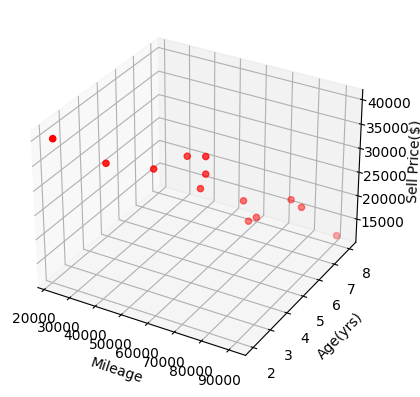

In [160]:
import matplotlib.pyplot as plt
# plot a scatter plot based on age, mileage and sell price
#plt.scatter(pd['Mileage'], pd['Sell Price($)'])
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# plot a scatter plot based on age, mileage and sell price using 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['Mileage'], df['Age(yrs)'], df['Sell Price($)'], c='r', marker='o')
ax.set_xlabel('Mileage')
ax.set_ylabel('Age(yrs)')
ax.set_zlabel('Sell Price($)')  # sell price is in dollars
plt.show()  # this will show 3D scatter plot

/Users/M365491/development/ai/py/.venv/lib/python3.11/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/M365491/development/ai/py/.venv/lib/python3.11/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


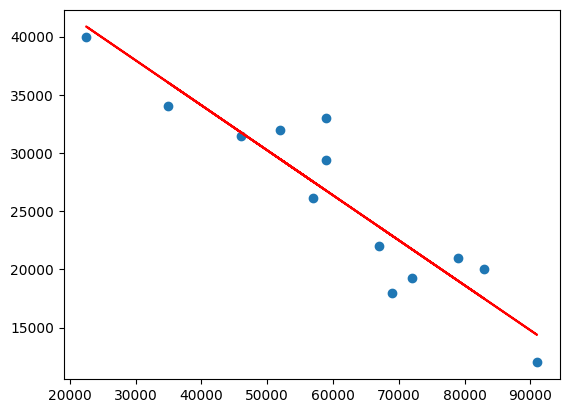

In [161]:
import matplotlib.pyplot as plt
# plot a scatter plot based on mileage, sell price along with best fit line
plt.scatter(df['Mileage'], df['Sell Price($)'])
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(df[['Mileage']], df['Sell Price($)']) # train the model
model.predict([[45000]]) # 45000 miles car price
model.predict([[86000]]) # 86000 miles car price
model.score(df[['Mileage']], df['Sell Price($)']) # accuracy of the model
plt.plot(df['Mileage'], model.predict(df[['Mileage']]), color='red')
plt.show()




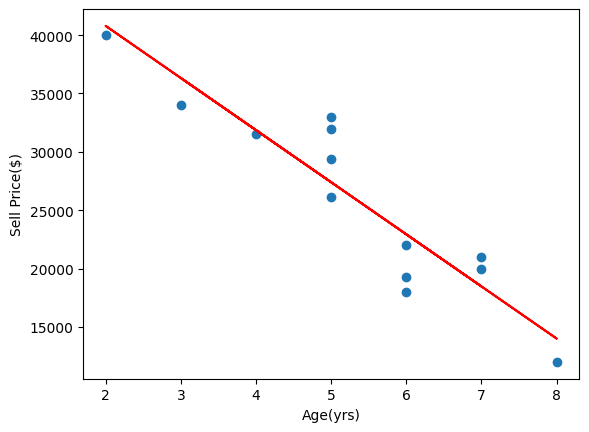

In [162]:
import matplotlib.pyplot as plt
# plot scatter plot based on age and sell price
# plt.scatter(df['Age(yrs)'], df['Sell Price($)'])
# plt.xlabel('Age(yrs)')
# plt.ylabel('Sell Price($)')
# plt.show()  # this will show scatter plot
# draw a line of best fit
import numpy as np
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(df[['Age(yrs)']], df['Sell Price($)'])
plt.scatter(df['Age(yrs)'], df['Sell Price($)'])
plt.plot(df['Age(yrs)'], model.predict(df[['Age(yrs)']]), color='red')
plt.xlabel('Age(yrs)')
plt.ylabel('Sell Price($)')
plt.show()  # this will show scatter plot with line of best fit


In [163]:
df

,Car Model,Mileage,Sell Price($),Age(yrs)
0,BMW X5,69000,18000,6
1,BMW X5,35000,34000,3
2,BMW X5,57000,26100,5
3,BMW X5,22500,40000,2
4,BMW X5,46000,31500,4
5,Audi A5,59000,29400,5
6,Audi A5,52000,32000,5
7,Audi A5,72000,19300,6
8,Audi A5,91000,12000,8
9,Mercedez Benz C class,67000,22000,6


In [164]:
# use label encoding to convert car names into numbers
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
dfle = df.copy()
dfle['Car Model'] = le.fit_transform(dfle['Car Model'])
dfle    # car names are converted into numbers


,Car Model,Mileage,Sell Price($),Age(yrs)
0,1,69000,18000,6
1,1,35000,34000,3
2,1,57000,26100,5
3,1,22500,40000,2
4,1,46000,31500,4
5,0,59000,29400,5
6,0,52000,32000,5
7,0,72000,19300,6
8,0,91000,12000,8
9,2,67000,22000,6


In [201]:
# transform car names into one hot encoded values
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
ct = ColumnTransformer([('Car Model', OneHotEncoder(), [0])], remainder = 'passthrough')    # 0 is the column number to transform
X = ct.fit_transform(dfle[["Car Model", 'Mileage', 'Age(yrs)']])
X  # car names are one hot encoded


array([[0.00e+00, 1.00e+00, 0.00e+00, 6.90e+04, 6.00e+00],
       [0.00e+00, 1.00e+00, 0.00e+00, 3.50e+04, 3.00e+00],
       [0.00e+00, 1.00e+00, 0.00e+00, 5.70e+04, 5.00e+00],
       [0.00e+00, 1.00e+00, 0.00e+00, 2.25e+04, 2.00e+00],
       [0.00e+00, 1.00e+00, 0.00e+00, 4.60e+04, 4.00e+00],
       [1.00e+00, 0.00e+00, 0.00e+00, 5.90e+04, 5.00e+00],
       [1.00e+00, 0.00e+00, 0.00e+00, 5.20e+04, 5.00e+00],
       [1.00e+00, 0.00e+00, 0.00e+00, 7.20e+04, 6.00e+00],
       [1.00e+00, 0.00e+00, 0.00e+00, 9.10e+04, 8.00e+00],
       [0.00e+00, 0.00e+00, 1.00e+00, 6.70e+04, 6.00e+00],
       [0.00e+00, 0.00e+00, 1.00e+00, 8.30e+04, 7.00e+00],
       [0.00e+00, 0.00e+00, 1.00e+00, 7.90e+04, 7.00e+00],
       [0.00e+00, 0.00e+00, 1.00e+00, 5.90e+04, 5.00e+00]])

In [202]:
X = X[:,1:]    # avoid dummy variable trap

In [203]:
X

array([[1.00e+00, 0.00e+00, 6.90e+04, 6.00e+00],
       [1.00e+00, 0.00e+00, 3.50e+04, 3.00e+00],
       [1.00e+00, 0.00e+00, 5.70e+04, 5.00e+00],
       [1.00e+00, 0.00e+00, 2.25e+04, 2.00e+00],
       [1.00e+00, 0.00e+00, 4.60e+04, 4.00e+00],
       [0.00e+00, 0.00e+00, 5.90e+04, 5.00e+00],
       [0.00e+00, 0.00e+00, 5.20e+04, 5.00e+00],
       [0.00e+00, 0.00e+00, 7.20e+04, 6.00e+00],
       [0.00e+00, 0.00e+00, 9.10e+04, 8.00e+00],
       [0.00e+00, 1.00e+00, 6.70e+04, 6.00e+00],
       [0.00e+00, 1.00e+00, 8.30e+04, 7.00e+00],
       [0.00e+00, 1.00e+00, 7.90e+04, 7.00e+00],
       [0.00e+00, 1.00e+00, 5.90e+04, 5.00e+00]])

In [204]:
y = dfle['Sell Price($)']
y

0     18000
1     34000
2     26100
3     40000
4     31500
5     29400
6     32000
7     19300
8     12000
9     22000
10    20000
11    21000
12    33000
Name: Sell Price($), dtype: int64

In [205]:
X, y

(array([[1.00e+00, 0.00e+00, 6.90e+04, 6.00e+00],
        [1.00e+00, 0.00e+00, 3.50e+04, 3.00e+00],
        [1.00e+00, 0.00e+00, 5.70e+04, 5.00e+00],
        [1.00e+00, 0.00e+00, 2.25e+04, 2.00e+00],
        [1.00e+00, 0.00e+00, 4.60e+04, 4.00e+00],
        [0.00e+00, 0.00e+00, 5.90e+04, 5.00e+00],
        [0.00e+00, 0.00e+00, 5.20e+04, 5.00e+00],
        [0.00e+00, 0.00e+00, 7.20e+04, 6.00e+00],
        [0.00e+00, 0.00e+00, 9.10e+04, 8.00e+00],
        [0.00e+00, 1.00e+00, 6.70e+04, 6.00e+00],
        [0.00e+00, 1.00e+00, 8.30e+04, 7.00e+00],
        [0.00e+00, 1.00e+00, 7.90e+04, 7.00e+00],
        [0.00e+00, 1.00e+00, 5.90e+04, 5.00e+00]]),
 0     18000
 1     34000
 2     26100
 3     40000
 4     31500
 5     29400
 6     32000
 7     19300
 8     12000
 9     22000
 10    20000
 11    21000
 12    33000
 Name: Sell Price($), dtype: int64)

In [207]:
# fit X and y values into linear regression model
from sklearn.linear_model import LinearRegression 
model = LinearRegression()
model.fit(X, y)   # train the model
print(model.predict([[0,0, 45000, 4]]))  # Mercedes Benz car with mileage 45000 and age 4 years
print(model.predict([[1, 0, 86000, 7]]))  # BMW car with mileage 86000 and age 7 years
model.score(X, y)  # accuracy of the model


[34537.77647335]
[11080.74313219]


0.9417050937281083